# Part 2: Success Rate Logic & Cohort Analysis 

## Part 2A: Operationalizing "Success"

**1. Mapping Status to a Binary Outcome:**
There is no explicit "success" flag in this dataset, so we must build a defensible proxy based on trial status:
* **Success (1):** Statuses marked as `Completed`. This indicates the trial reached its endpoints safely and successfully.
* **Failure (0):** Statuses marked as `Terminated`, `Suspended`, `Withdrawn`, or `Failed`. These represent trials that were halted due to toxicity, lack of efficacy, or lack of funding.

**2. Handling Ambiguous Statuses (Right-Censoring):**
Statuses such as `Recruiting`, `Not yet recruiting`, or `Active, not recruiting` are ambiguous. These trials are currently in progress and have neither succeeded nor failed yet. If we include them as "failures" or "successes," we will heavily skew the data (Right-Censoring Bias). Therefore, they are excluded entirely from this historical cohort analysis.

**3. Trial Completion vs. Therapeutic Success:**
It is important to note the caveat of this proxy: A Phase 1 trial that is "Completed" is an *operational* success (it proved the drug was safe), but it does not guarantee *therapeutic* success (that the drug actually cures the disease in Phase 3). For this broad portfolio analysis, we are measuring the operational completion rate.

In [33]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("--- STEP 1: LOADING DATA & CLEANING STRINGS ---")
# Load raw data directly to avoid any corrupted CSVs from Part 1
df = pd.read_csv('SampleDateExtract.xlsx - 1000_inteventional_trials.csv')

# Clean Status and Phase (Force uppercase and remove spaces to fix data formatting bugs)
df['status_clean'] = df['recruitment_status'].astype(str).str.upper().str.strip()
df['phase_clean'] = df['phase'].astype(str).str.upper().str.replace(' ', '').str.strip()

# Map Phase strings to Integers safely
phase_map = {
    'PHASE1': 1, 'PHASEI': 1, 'EARLYPHASE1': 0.5, 
    'PHASE1/PHASE2': 1.5, 'PHASE1/2': 1.5,
    'PHASE2': 2, 'PHASEII': 2, 
    'PHASE2/PHASE3': 2.5, 'PHASE2/3': 2.5,
    'PHASE3': 3, 'PHASEIII': 3, 
    'PHASE4': 4
}
df['phase_integer'] = df['phase_clean'].map(phase_map).fillna(-1)

print("--- STEP 2: APPLYING STANDARD SUCCESS PROXY ---")
# Filter for definitive endpoints (Excluding Ambiguous/Recruiting trials)
definitive_statuses = ['COMPLETED', 'TERMINATED', 'SUSPENDED', 'WITHDRAWN', 'FAILED']
historical_cohort = df[df['status_clean'].isin(definitive_statuses)].copy()

# The Standard Success Proxy: Completed = 1, Everything else = 0
historical_cohort['is_success'] = historical_cohort['status_clean'].apply(
    lambda x: 1 if x == 'COMPLETED' else 0
)

print(f"Total Raw Trials: {len(df)}")
print(f"Definitive Trials Analyzed (Ambiguous removed): {len(historical_cohort)}")
print(f"Global Portfolio Success Rate: {(historical_cohort['is_success'].mean() * 100):.1f}%")

--- STEP 1: LOADING DATA & CLEANING STRINGS ---
--- STEP 2: APPLYING STANDARD SUCCESS PROXY ---
Total Raw Trials: 1000
Definitive Trials Analyzed (Ambiguous removed): 620
Global Portfolio Success Rate: 73.1%


In [37]:
print("--- RAW COUNTS: SUCCESS VS FAILURE ---")
# Count the 0s and 1s in our simplified proxy column
counts = historical_cohort['is_success'].value_counts()

print(f"Failures (0): {counts[0]} trials")
print(f"Successes (1): {counts[1]} trials")
print(f"Total Definitive Trials Evaluated: {counts.sum()}")

print("--- WHAT HAPPENED TO THE MISSING 380 TRIALS? ---")

# Find all trials that were NOT in our definitive "historical_cohort"
definitive_statuses = ['COMPLETED', 'TERMINATED', 'SUSPENDED', 'WITHDRAWN', 'FAILED']
ongoing_trials = df[~df['status_clean'].isin(definitive_statuses)]

print(f"Total Ongoing/Ambiguous Trials: {len(ongoing_trials)}\n")
print("Here are their current statuses:")
print(ongoing_trials['status_clean'].value_counts())

--- RAW COUNTS: SUCCESS VS FAILURE ---
Failures (0): 167 trials
Successes (1): 453 trials
Total Definitive Trials Evaluated: 620
--- WHAT HAPPENED TO THE MISSING 380 TRIALS? ---
Total Ongoing/Ambiguous Trials: 380

Here are their current statuses:
status_clean
RECRUITING                 140
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64


## Part 2B: Stratified Cohort Analysis

Using our success proxy, we will calculate success rates broken down by three distinct dimensions:
1. **Indication vs. Global Average** (Bar Chart)
2. **Indication x Phase** (Heatmap)
3. **Temporal Trends over Time** (Line Chart)

*Note: Cohorts with fewer than 2 definitive trials have been suppressed from visualizations to reduce extreme statistical noise (e.g., 100% success rates based on a single trial).*

--- GENERATING STATIC CHARTS ---


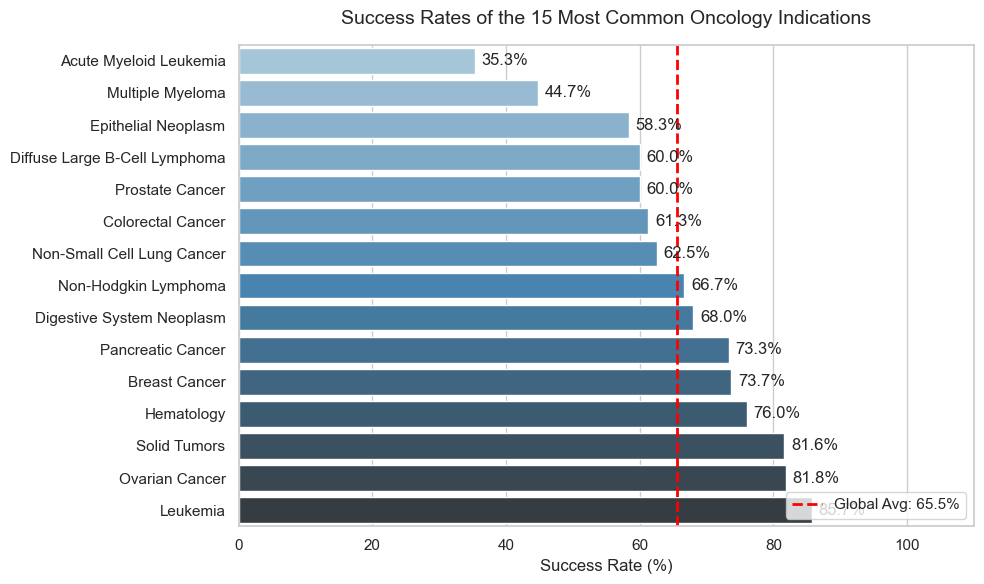

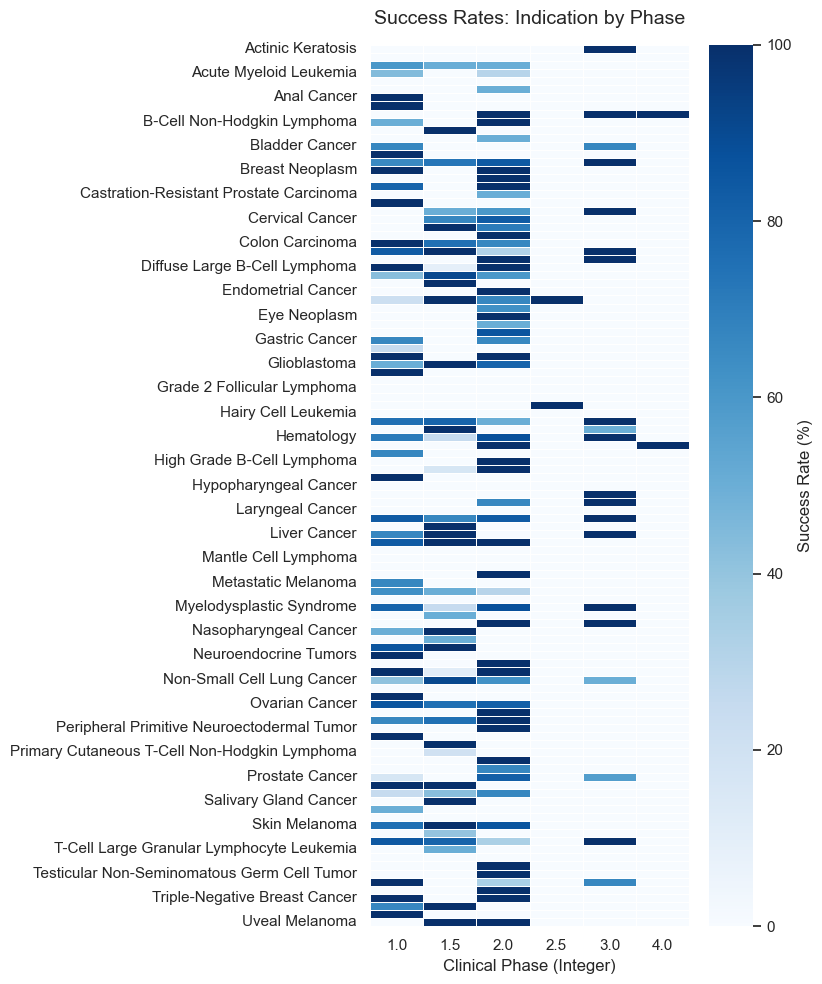

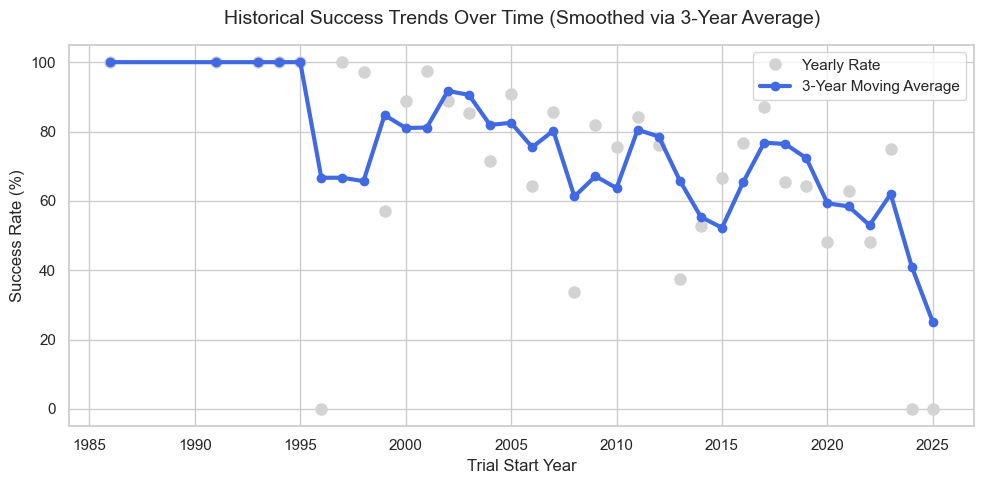

In [46]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING STATIC CHARTS ---")

# Set the visual style for the charts
sns.set_theme(style="whitegrid")

# --- PREP: Safely explode the indications column ---
def parse_list(val):
    if pd.isna(val): return []
    if isinstance(val, str) and val.startswith('['):
        try: return ast.literal_eval(val)
        except: return [val]
    return [val]

df_viz = historical_cohort.copy()
df_viz['ind_list'] = df_viz['indications'].apply(parse_list)
df_viz = df_viz.explode('ind_list')
df_viz['indication_clean'] = df_viz['ind_list'].astype(str).str.title().str.strip()

# ==========================================
# CHART 1: Top Indications (Bar Chart) 
# ==========================================
global_avg = df_viz['is_success'].mean() * 100

ind_stats = df_viz.groupby('indication_clean').agg(
    total_trials=('is_success', 'count'),
    success_rate=('is_success', 'mean')
).reset_index()

ind_stats['success_rate_%'] = ind_stats['success_rate'] * 100

# Top 15 most common diseases by volume, then sorted by success rate
top_volume_ind = ind_stats.sort_values('total_trials', ascending=False).head(15)
robust_ind = top_volume_ind.sort_values('success_rate_%', ascending=True)

plt.figure(figsize=(10, 6))
# Create the bar chart
ax = sns.barplot(data=robust_ind, x='success_rate_%', y='indication_clean', palette="Blues_d")

# Add the red average line
plt.axvline(global_avg, color='red', linestyle='--', linewidth=2, label=f'Global Avg: {global_avg:.1f}%')

# Add the percentage text to the end of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                va='center')

plt.title("Success Rates of the 15 Most Common Oncology Indications", fontsize=14, pad=15)
plt.xlabel("Success Rate (%)")
plt.ylabel("")
plt.xlim(0, 110)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# ==========================================
# CHART 2: Indication x Phase (Heatmap)
# ==========================================
heatmap_cohort = df_viz[df_viz['phase_integer'] > 0]
heatmap_stats = heatmap_cohort.groupby(['indication_clean', 'phase_integer']).agg(
    total_trials=('is_success', 'count'),
    success_rate=('is_success', 'mean')
).reset_index()

heatmap_stats['success_rate_%'] = heatmap_stats['success_rate'] * 100
robust_heatmap = heatmap_stats[heatmap_stats['total_trials'] >= 2]
heatmap_data = robust_heatmap.pivot(index='indication_clean', columns='phase_integer', values='success_rate_%').fillna(0)

plt.figure(figsize=(8, 10))
# CHANGED: Set annot=False to remove text inside the heatmap
sns.heatmap(heatmap_data, annot=False, cmap="Blues", cbar_kws={'label': 'Success Rate (%)'}, linewidths=.5)
plt.title("Success Rates: Indication by Phase", fontsize=14, pad=15)
plt.xlabel("Clinical Phase (Integer)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ==========================================
# CHART 3: Temporal Trends (Line Chart)
# ==========================================
df_viz['start_year'] = pd.to_datetime(df_viz['start_date'], errors='coerce').dt.year
temporal = df_viz.dropna(subset=['start_year']).groupby('start_year').agg(
    total_trials=('is_success', 'count'),
    success_rate=('is_success', 'mean')
).reset_index()

temporal['success_rate_%'] = temporal['success_rate'] * 100
temporal = temporal.sort_values('start_year')
temporal['3_Year_MA'] = temporal['success_rate_%'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(10, 5))
# Plot the raw data dots
plt.plot(temporal['start_year'], temporal['success_rate_%'], marker='o', linestyle='', color='lightgray', label='Yearly Rate', markersize=8)
# Plot the trendline
plt.plot(temporal['start_year'], temporal['3_Year_MA'], marker='o', linestyle='-', color='royalblue', linewidth=3, label='3-Year Moving Average')

plt.title("Historical Success Trends Over Time (Smoothed via 3-Year Average)", fontsize=14, pad=15)
plt.xlabel("Trial Start Year")
plt.ylabel("Success Rate (%)")
plt.ylim(-5, 105)
plt.legend()
plt.tight_layout()
plt.show()

# 🧬 Oncology Clinical Trial Data Pipeline: Conclusion

## Data Governance & Success Logic (Flowchart)
A critical component of this pipeline was accurately defining "Success" without falling victim to Right-Censoring Bias (evaluating ongoing trials prematurely). 

Below is the simple, logical architecture used to filter and score the raw dataset:
